# Inferring network from bulk data with CausFate

## Structure learning

### Preparations

Load packages

In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(foreach)
    library(dplyr)
    library(tidyr)
    library(bnlearn)
    library(Matrix)
    library(space)
    library(infotheo)
    library(igraph)
    library(graph)
    library(Rgraphviz)
})

library(causfate)

Setting plotting options for jupyter notebooks. These settings are not necessary when running the code in an R environment outside of jupyter notebooks.

In [2]:
options(repr.plot.format = "png", repr.plot.width = 5.5, repr.plot.height = 5.5)
options(jupyter.plot_mimetypes = "image/png")

### Load data

In [3]:
data("HMMA")
colnames(HMMA)[colnames(HMMA) == "pCFU-E"] <- "Ery"
head(HMMA)
dim(HMMA)

,HSC,MPPa,MPPb,sCMP,MEP,GMP,MkP,Ery,CLP,BLP,DN1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610005C13Rik,4.400000,4.420,4.170000,4.180000,4.250,4.370000,4.890000,4.320000,4.15,4.510000,4.19
0610006L08Rik,3.810000,3.950,4.030000,3.960000,4.390,4.460000,4.850000,4.540000,4.38,4.330000,4.28
0610007C21Rik,8.950000,6.340,7.650000,6.550000,8.040,8.630000,7.030000,7.390000,9.03,8.740000,8.68
0610007L01Rik,7.693333,8.320,8.423333,8.446667,9.300,9.876667,7.453333,8.023333,8.35,8.213333,7.69
0610007P08Rik,5.430000,5.742,6.088000,5.870000,6.166,5.790000,5.496000,5.682000,5.89,5.896000,5.63
0610007P14Rik,7.930000,7.700,7.760000,7.160000,8.820,8.820000,7.530000,7.540000,8.47,8.280000,7.85


[1] 21678    11

### Extract key genes

To accelerate the process, we only use the top 3000 genes for network learning. Here, we use `infotheo::mutinformation` to determine key gene markers.

In [4]:
ctypes <- colnames(HMMA)
# Binning expression values
HMMA_disc <- infotheo::discretize(HMMA) %>% as.matrix()

# Calculate the mutual information
doParallel::registerDoParallel(cores = 5)
HMMA_glist <- foreach(i = 1:nrow(HMMA), .combine = c) %dopar% {
  infotheo::mutinformation(HMMA_disc[i, ], ctypes)
}
names(HMMA_glist) <- rownames(HMMA)
HMMA_glist <- sort(HMMA_glist, decreasing = T)

### Structure learning

The Bayesian network structure is learned with `BNLearning`.

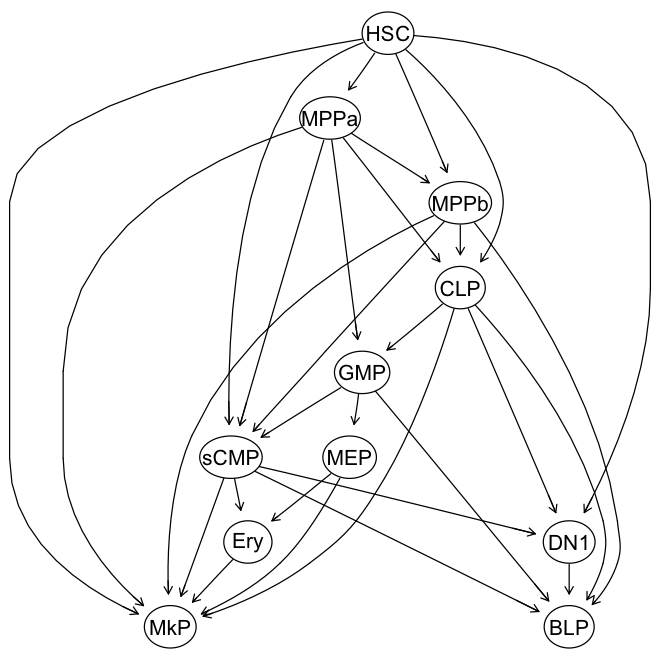

In [5]:
dat <- HMMA[names(HMMA_glist)[1:3000], ]
struc_smpls <- BNLearning(dat,
  params = seq(from = 0.08, to = 0.23, length.out = 10),
  root = "HSC", mode = "bulk", ncores = 5, ugMethod = "cmi2ni", dagMethod = "hc"
)
net_struc <- combineDAGs(struc_smpls, Emin = 20, Emax = 30)
net_struc <- rmCyc(net_struc)
e <- df2bn(net_struc, ctypes, plot = TRUE)

bnlearn::graphviz.plot(e, shape = "ellipse")

### Structure refining

In the following step, we make use of gene variability information to prune our graph with `trimDAG`.

`trimDAG` automatically plots the modified structure for you. This feature can be turned off by setting `plot = FALSE`.

In [6]:
outputDAG <- trimDAG(HMMA, e, 2, 3, .9, plot = FALSE)

Color the graphs with respect to reference network.

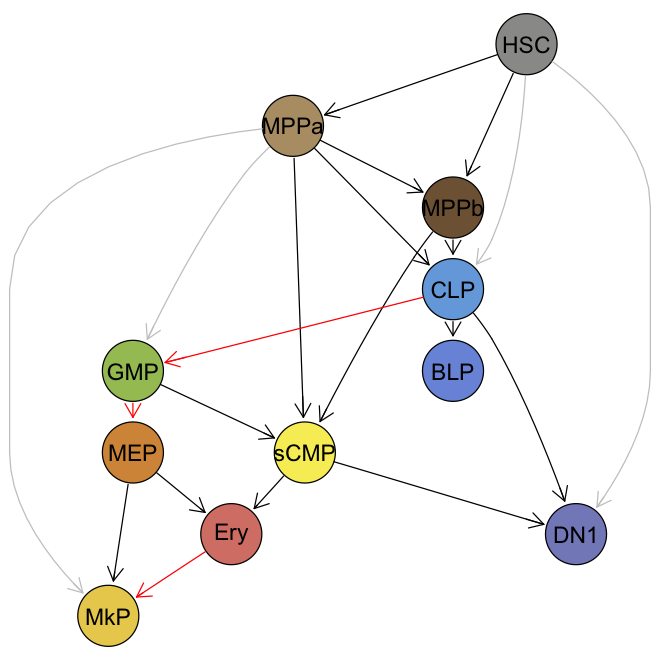

In [7]:
node_col <- c(
  "HSC" = "#9A9A99",
  "MPPa" = "#B69D75",
  "MPPb" = "#806342",
  "CLP" = "#76A9E0",
  "GMP" = "#A4C362",
  "MEP" = "#D59546",
  "Ery" = "#D88176",
  "MkP" = "#EACF5C",
  "DN1" = "#838BC3",
  "sCMP" = "#F6ED64",
  "BLP" = "#7A97DC"
)
ref_net <- bnlearn::model2network("[HSC][MPPa|HSC][MPPb|HSC:MPPa][CMP|MPPa:MPPb][CLP|MPPa:MPPb][MEP|CMP][GMP|CMP][BLP|CLP][DN1|CLP][Ery|MEP][MkP|MEP]")
colorEdges(outputDAG, ref_net, 
           node_col = node_col, 
           fontsize = 13, 
           node_size = 3,
           sep = 0.8)

## Calculate gene-wise causal effects

Having learnt the network structure, following functions are used to extract causal information of genes.

`PerturbResult`: calculates the BN coefficients after gene perturbation. The HMMA example below explicitly uses `deletion = TRUE`, matching the operation used for the manuscript's bulk/microarray analyses. The updated software otherwise defaults to zeroing: `deletion = FALSE, perturb_ratio = 0`. Ratios strictly between 0 and 1 scale values down (knockdown), ratios above 1 scale values up (knockup), and 1 leaves them unchanged. Graded scaling was not used in the reported analyses.

`EffectMatrix`: use `dist_metric = 'diff_mean'` for the existing signed sum of coefficient differences. `diffScore(abs = TRUE)` applies the absolute value when scoring. Other case-insensitive choices are W1, W2, energy and mmd (for example, `dist_metric = 'w2'` or `'MMD'`). Legacy `mode` calls remain supported.

`diffScore`: calculates gene contribution to a subset of edges.

`dsRank`: gives ranked gene list according to previous scores.

In [8]:
perturbRes <- PerturbResult(
  net_struc = outputDAG,
  data = HMMA,
  mode = "bulk", # GRN-free single-feature perturbation
  deletion = TRUE,
  ncores = 1
)
effMat <- EffectMatrix(perturbRes, dist_metric = "diff_mean")

edgeSet <- setEdges(fromSet = ctypes, toSet = ctypes) # Calculate for all edges
effectScore <- diffScore(effMat, edgeSet)
geneList <- dsRank(effectScore)
head(geneList)

[1] "Gm10883 or Gm1420 or Gm7202 or Igk-C or Igk-J1 or Igk-V28"
[2] "Car1"                                                     
[3] "Pf4"                                                      
[4] "Mpo"                                                      
[5] "Gm10482"                                                  
[6] "Aldh1a1"